In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
if os.getcwd().endswith('notebooks'):
    os.chdir('..')
print(f"Project Root: {os.getcwd()}")
df = pd.read_csv('data/raw/train.csv')
print(df.head())
print(df.tail())

Project Root: C:\Users\chihe\Documents\projects\mlops\mlops-gcp-project1
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000

In [2]:
print(df.shape)
print(df.info())
print(df.describe())
print(df.dtypes)

(891, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842 

In [9]:
print(df.isnull().sum())
df.isnull().sum() / len(df) * 100  # percentage

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

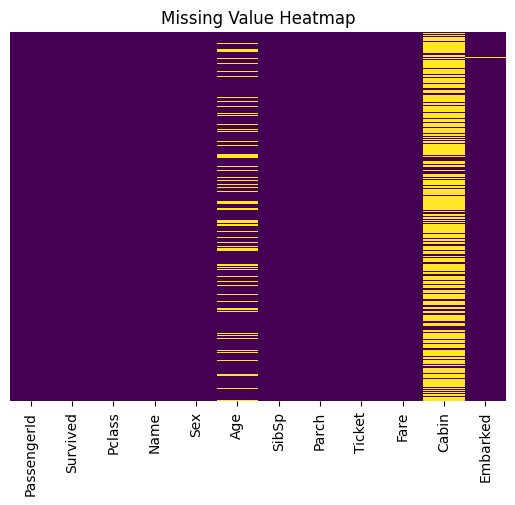

In [4]:
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Missing Value Heatmap')
plt.show()

In [ ]:
# Age: ~19% missing — needs imputation (median imputation is standard)
# Cabin: ~77% missing — too many, will drop this column
# Embarked: 2 missing — impute with mode (most frequent value)

In [8]:
print(df['Survived'].value_counts())
df['Survived'].value_counts(normalize=True)  # proportions


Survived
0    549
1    342
Name: count, dtype: int64


Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

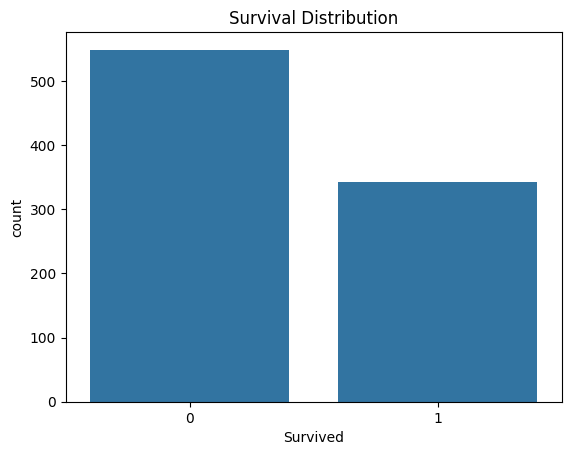

In [7]:

sns.countplot(x='Survived', data=df)
plt.title('Survival Distribution')
plt.show()

<Axes: xlabel='Sex', ylabel='Survived'>

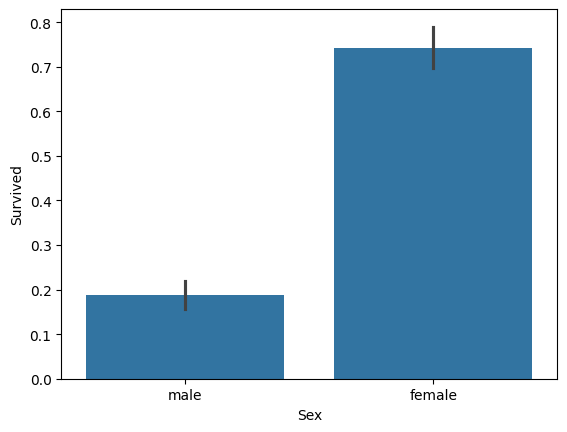

In [10]:
sns.barplot(x='Sex', y='Survived', data=df)

<Axes: xlabel='Pclass', ylabel='Survived'>

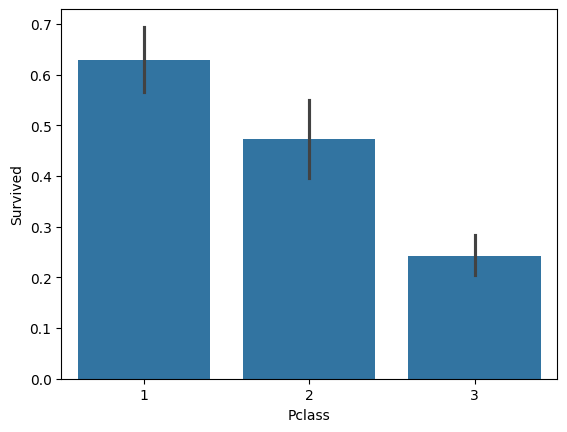

In [11]:
sns.barplot(x='Pclass', y='Survived', data=df)

<Axes: xlabel='Pclass', ylabel='Survived'>

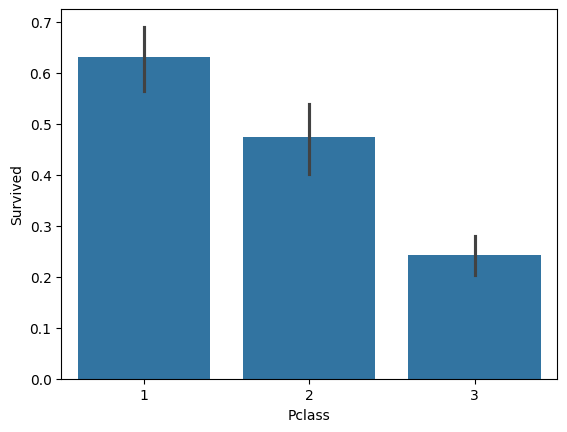

In [12]:
sns.barplot(x='Pclass', y='Survived', data=df)

<Axes: xlabel='Age', ylabel='Count'>

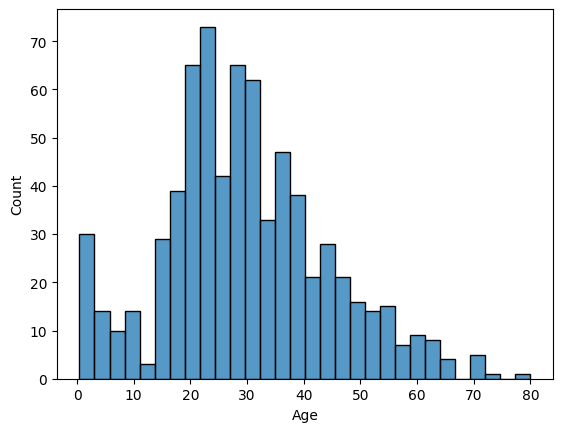

In [13]:
sns.histplot(df['Age'].dropna(), bins=30)

<Axes: xlabel='Age', ylabel='Count'>

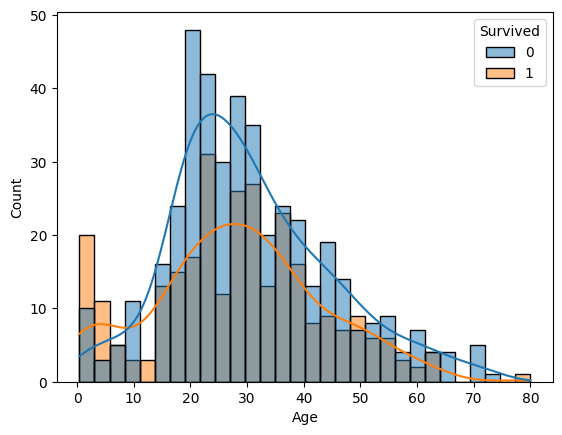

In [14]:
sns.histplot(data=df, x='Age', hue='Survived', bins=30, kde=True)

<Axes: xlabel='Fare', ylabel='Count'>

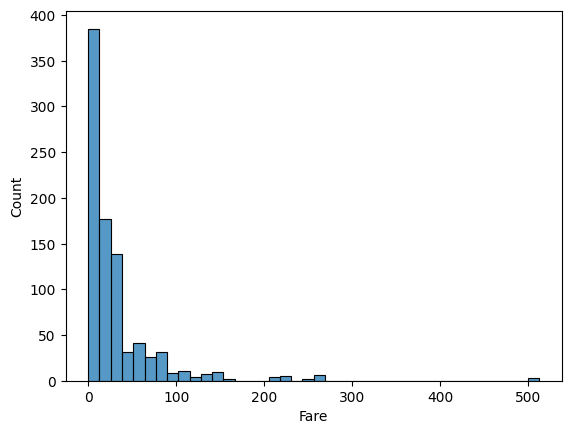

In [15]:
sns.histplot(df['Fare'], bins=40)

<Axes: xlabel='SibSp', ylabel='Survived'>

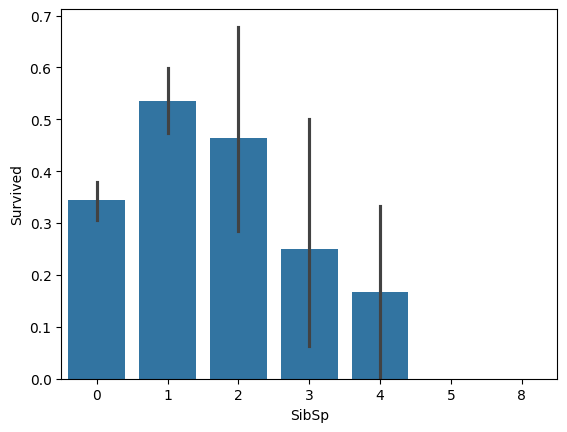

In [20]:
sns.barplot(x='SibSp', y='Survived', data=df)

<Axes: xlabel='Parch', ylabel='Survived'>

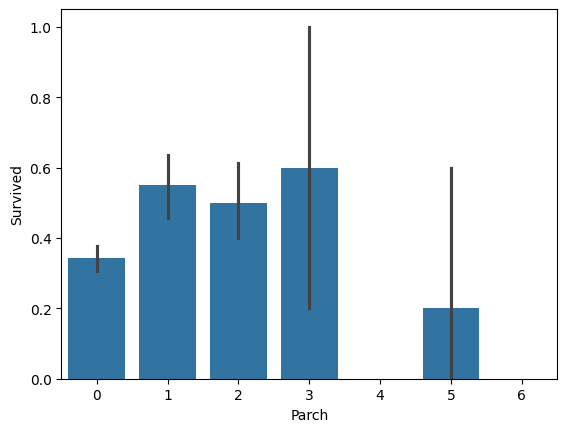

In [21]:
sns.barplot(x='Parch', y='Survived', data=df)

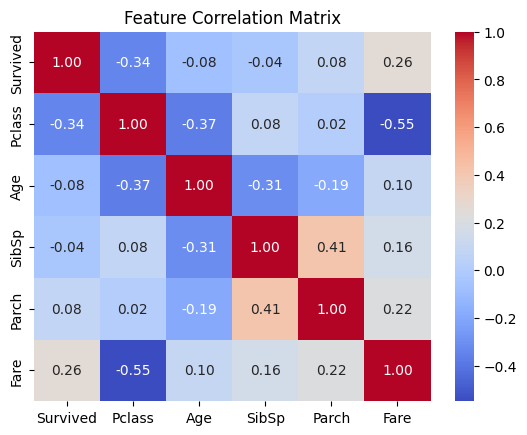

In [22]:
# For numeric columns only
numeric_df = df[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']]
correlation_matrix = numeric_df.corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.show()

In [23]:
# ==============================================================================
# FEATURE ENGINEERING STRATEGY
# ==============================================================================

# 1. Columns to DROP:
# - PassengerId: Unique ID, no predictive value
# - Name: Too high cardinality (too many unique strings)
# - Ticket: Noisy, no clear pattern
# - Cabin: ~77% missing, too much information loss

# 2. Columns to IMPUTE (Fill missing values):
# - Age: Impute with MEDIAN (robust to outliers/skewed distribution)
# - Embarked: Impute with MODE (most frequent value: 'S')

# 3. Columns to ENCODE (Convert text to numbers):
# - Sex: Binary encode (male=0, female=1)
# - Embarked: One-hot encode (creates Embarked_C, Embarked_Q, Embarked_S)

# 4. Columns to KEEP as-is:
# - Pclass, SibSp, Parch, Fare, Survived

# 5. New Features to ENGINEER:
# - FamilySize: SibSp + Parch + 1 (To capture family survival dynamics)
# - IsAlone: 1 if FamilySize == 1, else 0
# ==============================================================================

In [29]:
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Load Data
df = pd.read_csv("data/raw/train.csv")

# 2. Drop columns (inplace=True is okay here, but let's be explicit)
df = df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)

# 3. Impute (FIXED: No more 'inplace=True')
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# 4. Feature engineering
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

# 5. Encode
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
# get_dummies converts text categories like 'S', 'C', 'Q' into separate columns
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

# 6. Split Features (X) and Target (y)
X = df.drop('Survived', axis=1)
y = df['Survived']

# 7. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train shape: {X_train.shape}")
print(f"y_train distribution:\n{y_train.value_counts(normalize=True)}")

X_train shape: (712, 10)
y_train distribution:
Survived
0    0.616573
1    0.383427
Name: proportion, dtype: float64


In [30]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred))

Accuracy: 0.8268
F1 Score: 0.7669
              precision    recall  f1-score   support

           0       0.84      0.88      0.86       110
           1       0.80      0.74      0.77        69

    accuracy                           0.83       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.83      0.83      0.83       179



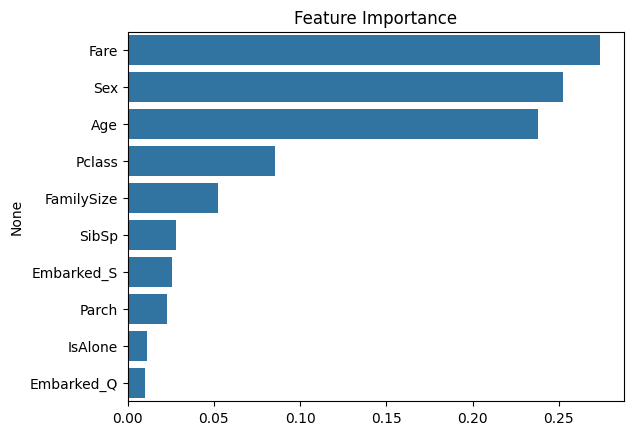

In [31]:
feature_importance = pd.Series(
    model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

sns.barplot(x=feature_importance.values, y=feature_importance.index)
plt.title('Feature Importance')
plt.show()